# Imports

In [1]:
import numpy as np
import pandas as pd
import glob
import os
import random

import cv2
import tensorflow as tf
import tfimm
import timm
from builtins import range, input
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

import torch
import torch_geometric
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
import torch.nn.functional as F

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Hyperparameters

# PVTAD models
vis_epochs = 20
vis_batch_size = 32

# GNN models
gnn_epochs = 50 # Graph data may require fewer epochs to converge
gnn_batch_size = 64 # Graph data is smaller so we can use a larger batch size for training
hidden_channels = 32
dropout = 0.5
weight_decay = 0.00005
k_neighbors = 10 # Each node will be connected only to its k nearest neighbors
random_state = random.randint(0, 10000)
print(f"Random state: {random_state}")
heads = 4

Random state: 2227


# Data Loading and FC Matrix Computation

In [3]:
# Compute Pearson Correlation Matrix

def compute_fc_matrix(filepath):
    # Each .1D file: rows = timepoints, columns = ROIs
    timeseries = np.loadtxt(filepath)  # shape: (T, n_rois)
    fc_matrix = np.corrcoef(timeseries.T)  # transpose so corrcoef treats ROIs as variables
    return fc_matrix

# Example: process every downloaded file
filepaths = glob.glob('./data/abide_aal_data/Outputs/cpac/filt_global/rois_cc200/*.1D')  # adjust path/pattern to match your download
fc_matrices = {}

for fp in filepaths:
    file_id = os.path.basename(fp).replace('_rois_cc200.1D', '')  # strip suffix to get FILE_ID
    fc_matrices[file_id] = compute_fc_matrix(fp)

print(f"Processed {len(fc_matrices)} subjects")
print(f"Matrix shape: {next(iter(fc_matrices.values())).shape}")  # should be (200, 200) for CC200

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processed 884 subjects
Matrix shape: (200, 200)


In [4]:
# Count the number of subjects that have 0 standard deviation

nan_counts = {}
for file_id, matrix in fc_matrices.items():
    n_nan = np.isnan(matrix).sum()
    if n_nan > 0:
        nan_counts[file_id] = n_nan

print(f"{len(nan_counts)} of {len(fc_matrices)} subjects have NaNs")
if nan_counts:
    # show the worst few
    worst = sorted(nan_counts.items(), key=lambda x: -x[1])[:5]
    print("Worst offenders:", worst)

35 of 884 subjects have NaNs
Worst offenders: [('Caltech_0051478', 33276), ('Caltech_0051469', 25600), ('SDSU_0050209', 10071), ('SDSU_0050216', 6144), ('Caltech_0051471', 5404)]


In [5]:
# Remove NaN subjects from the dictionary of matrices

fc_matrices_clean = {fid: mat for fid, mat in fc_matrices.items() if not np.isnan(mat).any()}
print(f"Kept {len(fc_matrices_clean)} of {len(fc_matrices)} subjects")

Kept 849 of 884 subjects


# Phenotypic Label Merge

In [6]:
# Merge subject data with phenotypic labels

pheno = pd.read_csv('./data/Phenotypic_V1_0b_preprocessed1.csv')

# Build labels lookup
labels = pheno[['FILE_ID', 'DX_GROUP', 'SEX', 'AGE_AT_SCAN', 'func_mean_fd', 'SITE_ID']].copy()
labels = labels[labels['FILE_ID'] != 'no_filename']

# Merge with your CLEAN matrices
matched_data = []
for file_id, matrix in fc_matrices_clean.items():
    row = labels[labels['FILE_ID'] == file_id]
    if not row.empty:
        dx = row['DX_GROUP'].values[0]
        sex = row['SEX'].values[0] # ABIDE coding: 1=Male, 2=Female
        age = row['AGE_AT_SCAN'].values[0]
        mean_fd = row['func_mean_fd'].values[0]
        site = row['SITE_ID'].values[0]
        matched_data.append((file_id, matrix, dx, sex, age, mean_fd, site))

print(f"Matched {len(matched_data)} of {len(fc_matrices_clean)} subjects to labels")
print(matched_data)

Matched 849 of 849 subjects to labels
[('Caltech_0051459', array([[ 1.        , -0.1773661 , -0.00602314, ..., -0.28906846,
        -0.34674923,  0.00569531],
       [-0.1773661 ,  1.        ,  0.23651303, ...,  0.17127448,
        -0.06847432, -0.31333132],
       [-0.00602314,  0.23651303,  1.        , ..., -0.07478013,
        -0.01658607, -0.04234176],
       ...,
       [-0.28906846,  0.17127448, -0.07478013, ...,  1.        ,
         0.03017183, -0.22089793],
       [-0.34674923, -0.06847432, -0.01658607, ...,  0.03017183,
         1.        , -0.17733803],
       [ 0.00569531, -0.31333132, -0.04234176, ..., -0.22089793,
        -0.17733803,  1.        ]]), 1, 1, 22.8, 0.0413318031, 'CALTECH'), ('Caltech_0051461', array([[ 1.        , -0.23663444, -0.22839338, ...,  0.32799874,
         0.13613338,  0.0465256 ],
       [-0.23663444,  1.        ,  0.46683256, ...,  0.01660224,
        -0.07951879, -0.301523  ],
       [-0.22839338,  0.46683256,  1.        , ..., -0.00145756,
    

In [7]:
import collections
labels_only = [dx for (_, _, dx, _, _, _, _) in matched_data]
print(collections.Counter(labels_only))

Counter({2: 458, 1: 391})


In [8]:
# Separate matrices by diagnosis group

ASD_matrices = [(fid, mat) for (fid, mat, dx, sex, age, mean_fd, site) in matched_data if dx == 1]
TDC_matrices = [(fid, mat) for (fid, mat, dx, sex, age, mean_fd, site) in matched_data if dx == 2]

print(f"ASD subjects: {len(ASD_matrices)}")
print(f"TDC subjects: {len(TDC_matrices)}")

ASD subjects: 391
TDC subjects: 458


# Preprocessing and Normalization

##### Vision models

In [9]:
# Build X and y arrays from matched_data
X_vis = np.array([mat for (_, mat, _, _, _, _, _) in matched_data])  # shape: (849, 200, 200)
y = np.array([dx for (_, _, dx, _, _, _, _) in matched_data])    # shape: (849,)

# Normalize: map correlation values from [-1, 1] to [0, 1]
X_vis = (X_vis + 1) / 2

print(f"X_vis shape: {X_vis.shape}")
print(f"y shape: {y.shape}")
print(f"X_vis min: {X_vis.min():.4f}, X_vis max: {X_vis.max():.4f}")  # should be ~0.0 to ~1.0

# Convert ABIDE coding (1=ASD, 2=TDC) to binary (1=ASD, 0=TDC)
y = (y == 1).astype(np.int32)

print(collections.Counter(y))  # should show {0: 458, 1: 391}


X_vis shape: (849, 200, 200)
y shape: (849,)
X_vis min: 0.0204, X_vis max: 1.0000
Counter({0: 458, 1: 391})


##### Graph models

In [10]:
# Build a second, non-rescaled version of the FC matrices for GNN
# (top-k sparsification needs real correlation sign/magnitude, not [0,1]-rescaled values)

X_gnn = np.array([mat for (_, mat, _, _, _, _, _) in matched_data])  # shape: (849, 200, 200), raw correlations
y = np.array([dx for (_, _, dx, _, _, _, _) in matched_data])   # why use an underscore instead of, for example, (_, _, dx, sex, age, mean_fd)?

# Convert ABIDE coding (1=ASD, 2=TDC) to binary (1=ASD, 0=TDC)
y = (y == 1).astype(np.int32)

sex_raw = np.array([sex for (_, _, _, sex, _, _, _) in matched_data], dtype=np.float32)
age_raw = np.array([age for (_, _, _, _, age, _, _) in matched_data], dtype=np.float32)
fd_raw  = np.array([fd for (_, _, _, _, _, fd, _) in matched_data], dtype=np.float32)
site_raw = np.array([site for (_, _, _, _, _, _, site) in matched_data])

sex_bin = (sex_raw == 2).astype(np.float32)  # 0 = male, 1 = female

#print(f"X_gnn shape: {X_gnn.shape}")
#print(f"X_gnn min: {X_gnn.min():.4f}, X_gnn max: {X_gnn.max():.4f}")  # should be close to -1.0 to 1.0
# Replaced above 2 with below 2
print(collections.Counter(sex_bin))
print(f"Age range: {age_raw.min():.1f}-{age_raw.max():.1f}, mean_fd range: {fd_raw.min():.3f}-{fd_raw.max():.3f}")

Counter({0.0: 716, 1.0: 133})
Age range: 6.5-64.0, mean_fd range: 0.016-0.200


In [11]:
from sklearn.preprocessing import OneHotEncoder

site_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
site_onehot = site_encoder.fit_transform(site_raw.reshape(-1, 1)).astype(np.float32)
num_sites = site_onehot.shape[1]
print(f"Encoding {num_sites} sites: {site_encoder.categories_[0]}")

Encoding 20 sites: ['CALTECH' 'CMU' 'KKI' 'LEUVEN_1' 'LEUVEN_2' 'MAX_MUN' 'NYU' 'OHSU' 'OLIN'
 'PITT' 'SBL' 'SDSU' 'STANFORD' 'TRINITY' 'UCLA_1' 'UCLA_2' 'UM_1' 'UM_2'
 'USM' 'YALE']


# Train Val Test Split

##### Vision models

In [12]:
from sklearn.model_selection import train_test_split

# First split: train (70%) vs. temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_vis, y, test_size=0.3, stratify=y, random_state=random_state
)

# Second split: val (15%) vs. test (15%) from the temp 30%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=random_state
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train labels: {collections.Counter(y_train)}")
print(f"Val labels:   {collections.Counter(y_val)}")
print(f"Test labels:  {collections.Counter(y_test)}")

Train: 594, Val: 127, Test: 128
Train labels: Counter({0: 320, 1: 274})
Val labels:   Counter({0: 69, 1: 58})
Test labels:  Counter({0: 69, 1: 59})


##### Graph models

In [13]:
# Parallel split for the GNN's raw FC matrices — identical partition of subjects,
# since it uses the same y array, same test_size, same random_state as the split above

(X_train_gnn, X_temp_gnn, y_train_gnn, y_temp_gnn,
 sex_train, sex_temp, age_train, age_temp, fd_train, fd_temp, site_train, site_temp) = train_test_split(
    X_gnn, y, sex_bin, age_raw, fd_raw, site_onehot, test_size=0.3, stratify=y, random_state=random_state
)

(X_val_gnn, X_test_gnn, y_val_gnn, y_test_gnn,
 sex_val, sex_test, age_val, age_test, fd_val, fd_test, site_val, site_test) = train_test_split(
    X_temp_gnn, y_temp_gnn, sex_temp, age_temp, fd_temp, site_temp, test_size=0.5, stratify=y_temp_gnn, random_state=random_state
)

# standardize age and mean_fd for GNN
age_mean, age_std = age_train.mean(), age_train.std()
fd_mean, fd_std = fd_train.mean(), fd_train.std()

age_train_z = (age_train - age_mean) / age_std
age_val_z   = (age_val   - age_mean) / age_std
age_test_z  = (age_test  - age_mean) / age_std

fd_train_z = (fd_train - fd_mean) / fd_std
fd_val_z   = (fd_val   - fd_mean) / fd_std
fd_test_z  = (fd_test  - fd_mean) / fd_std

print(f"Graph train: {len(X_train_gnn)}, val: {len(X_val_gnn)}, test: {len(X_test_gnn)}")

Graph train: 594, val: 127, test: 128


# Model Definition ----------------

##### Reshape data for vision transformers

In [14]:
import tensorflow as tf
from keras.layers import Input

# Resize and tile X arrays to match pretrained backbone expectations
# Commented out the below 3 lines (Change A)
X_train_model = tf.image.resize(X_train[..., np.newaxis], [224, 224]).numpy()
X_val_model   = tf.image.resize(X_val[..., np.newaxis],   [224, 224]).numpy()
X_test_model  = tf.image.resize(X_test[..., np.newaxis],  [224, 224]).numpy()
# Replaced below 3 with above 3 (Original i think)
# Tile single channel to 3 channels (pretrained models expect RGB-like input)
X_train_model = np.repeat(X_train_model, 3, axis=-1)
X_val_model   = np.repeat(X_val_model,   3, axis=-1)
X_test_model  = np.repeat(X_test_model,  3, axis=-1)

# Input shape variable used by all three models
cnn_inp_y = Input(shape=(224, 224, 3)) # Changed from (224, 224, 3) to (200, 200, 3) (Change A)
inp_y = Input(shape=(224, 224, 3)) # Added for ViT model (Change C)

print(f"X_train_model shape: {X_train_model.shape}")  # should be (594, 224, 224, 3)
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")


X_train_model shape: (594, 224, 224, 3)
X_val_model shape:   (127, 224, 224, 3)
X_test_model shape:  (128, 224, 224, 3)


##### Sparsify FC matrices for GNN

In [15]:
# Function definitions
def sparsify_topk(fc_matrix, k=k_neighbors):
    n = fc_matrix.shape[0]
    mask = np.zeros_like(fc_matrix, dtype=bool)

    for i in range(n):
        row = fc_matrix[i].copy()
        row[i] = 0  # exclude self-loop; GCNConv adds these separately
        top_k_idx = np.argsort(-np.abs(row))[:k]
        mask[i, top_k_idx] = True

    # Union symmetrization: keep edge if either direction was selected
    mask = mask | mask.T

    sparsified = np.where(mask, fc_matrix, 0.0)
    return sparsified

def matrix_to_data(dense_fc_matrix, label, sex, age, mean_fd, site_vec, k=k_neighbors):
    sparse_fc = sparsify_topk(dense_fc_matrix, k=k)

    # edge_index: 2 x E array of [source, target] pairs for every surviving edge
    src, tgt = np.nonzero(sparse_fc)
    edge_index = torch.tensor(np.array([src, tgt]), dtype=torch.long)

    # edge_attr: correlation value for each surviving edge, matching edge_index order
    #edge_attr = torch.tensor(sparse_fc[src, tgt], dtype=torch.float)
    # Changed above to below
    edge_attr = torch.tensor(np.abs(sparse_fc[src, tgt]), dtype=torch.float)

    # Node features: full dense row per node (Option 2 — not sparsified)
    x = torch.tensor(dense_fc_matrix, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)
    covariates = torch.tensor(
        np.concatenate([[sex, age, mean_fd], site_vec]).reshape(1, -1),
        dtype=torch.float
    )  # shape [1, 3 + num_sites]


    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, covariates=covariates)

In [16]:
# Making the datasets
#train_dataset_gnn = [matrix_to_data(X_train_gnn[i], y_train_gnn[i]) for i in range(len(X_train_gnn))]
#val_dataset_gnn   = [matrix_to_data(X_val_gnn[i],   y_val_gnn[i])   for i in range(len(X_val_gnn))]
#test_dataset_gnn  = [matrix_to_data(X_test_gnn[i],  y_test_gnn[i])  for i in range(len(X_test_gnn))]
# Above to below
train_dataset_gnn = [matrix_to_data(X_train_gnn[i], y_train_gnn[i], sex_train[i], age_train_z[i], fd_train_z[i], site_train[i]) for i in range(len(X_train_gnn))]
val_dataset_gnn   = [matrix_to_data(X_val_gnn[i],   y_val_gnn[i],   sex_val[i],   age_val_z[i],   fd_val_z[i], site_val[i])   for i in range(len(X_val_gnn))]
test_dataset_gnn  = [matrix_to_data(X_test_gnn[i],  y_test_gnn[i],  sex_test[i],  age_test_z[i],  fd_test_z[i], site_test[i])  for i in range(len(X_test_gnn))]

print(f"Train graphs: {len(train_dataset_gnn)}, Val: {len(val_dataset_gnn)}, Test: {len(test_dataset_gnn)}")
print(train_dataset_gnn[0])  # sanity check — should show x=[200, 200], edge_index=[2, E], y=[1]

Train graphs: 594, Val: 127, Test: 128
Data(x=[200, 200], edge_index=[2, 2612], edge_attr=[2612], y=[1], covariates=[1, 23])


##### Vision model definitions

**CNN (ResNet)**

In [17]:
base_model_cnn = tfimm.create_model("resnet18", pretrained="timm", nb_classes=0)

for layer_cnn in base_model_cnn.layers:
    layer_cnn.trainable = False # Changed from False to True
out_cnn = base_model_cnn(inp_y)

out_cnn = Dense(64, activation='relu')(out_cnn)
out_cnn = Dropout(0.5)(out_cnn)
output = Dense(2, activation='softmax')(out_cnn)

model_cnn = Model(inputs=[inp_y], outputs=output)
model_cnn.summary()

All PyTorch model weights were used when initializing ResNet.
All the weights of ResNet were initialized from the PyTorch model.



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet18 (ResNet)           (None, 512)               11186112  
                                                                 
 dense (Dense)               (None, 64)                32832     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 2)                 130       
                                                                 
Total params: 11219074 (42.80 MB)
Trainable params: 32962 (128.76 KB)
Non-trainable params: 11186112 (42.67 MB)
_________________________________________________________________


In [18]:
print("model_cnn.output_shape: ", model_cnn.output_shape)

print("y_train.shape: ", y_train.shape)
print("y_val.shape: ", y_val.shape)

print("y_train[:5]: ", y_train[:5])

model_cnn.output_shape:  (None, 2)
y_train.shape:  (594,)
y_val.shape:  (127,)
y_train[:5]:  [0 0 0 1 1]


**ViT**

In [19]:
base_model_vit = tfimm.create_model("vit_tiny_patch16_224", pretrained="timm", nb_classes=0)

for layer_vit in base_model_vit.layers:
    layer_vit.trainable = False # Changed from False to True
out_vit = base_model_vit(inp_y)
out_vit = Flatten()(out_vit)

output = Dense(2, activation='softmax')(out_vit)
model_vit = Model(inputs=[inp_y], outputs=output)
model_vit.summary()

All PyTorch model weights were used when initializing ViT.
All the weights of ViT were initialized from the PyTorch model.



Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vit_tiny_patch16_224 (ViT)  (None, 192)               5524416   
                                                                 
 flatten_2 (Flatten)         (None, 192)               0         
                                                                 
 dense_2 (Dense)             (None, 2)                 386       
                                                                 
Total params: 5524802 (21.08 MB)
Trainable params: 38402 (150.01 KB)
Non-trainable params: 5486400 (20.93 MB)
_________________________________________________________________


**Pyramid ViT**

In [20]:
base_model_pvt = tfimm.create_model("pvt_tiny", pretrained="timm", nb_classes=0)

for layer_pvt in base_model_pvt.layers:
    layer_pvt.trainable = False # Changed from False to True
out_pvt = base_model_pvt(inp_y)
out_pvt = Flatten()(out_pvt)

output = Dense(2, activation='softmax')(out_pvt)
model_pvt = Model(inputs=[inp_y], outputs=output)
model_pvt.summary()

All PyTorch model weights were used when initializing PyramidVisionTransformer.
All the weights of PyramidVisionTransformer were initialized from the PyTorch model.



Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 pvt_tiny (PyramidVisionTra  (None, 512)               12716288  
 nsformer)                                                       
                                                                 
 flatten_3 (Flatten)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 12717314 (48.51 MB)
Trainable params: 390914 (1.49 MB)
Non-trainable params: 12326400 (47.02 MB)
_________________________________________________________________


#### GNN model definition

##### GCN

In [21]:
class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, dropout, num_covariates=3 + num_sites):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.lin1 = torch.nn.Linear(hidden_channels + num_covariates, hidden_channels // 2)
        self.lin2 = torch.nn.Linear(hidden_channels // 2, 2)

        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch, covariates):
        # Layer 1: message passing + activation
        x = self.conv1(x, edge_index, edge_weight=edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: message passing + activation
        x = self.conv2(x, edge_index, edge_weight=edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Collapse each graph's 200 node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)
        x = torch.cat([x, covariates], dim=1)

        # Classifier head
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x  # raw logits — softmax handled by the loss function, not here

In [22]:
## Initialize GCN model

num_node_features = train_dataset_gnn[0].num_node_features  # 200 for CC200

model_gcn = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout)
print(model_gcn)

GCN(
  (conv1): GCNConv(200, 32)
  (conv2): GCNConv(32, 32)
  (lin1): Linear(in_features=55, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=2, bias=True)
)


In [23]:
# Determine which device to use
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gcn = model_gcn.to(device)
print(f"Using device: {device}")

Using device: cpu


##### GAT

In [24]:
class GAT(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, dropout, heads, edge_dim=1, num_covariates=3 + num_sites): # Might need to be 3 + num_sites
        super().__init__()
        self.conv1 = GATConv(num_node_features, hidden_channels, dropout=dropout, heads=heads, edge_dim=edge_dim)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, dropout=dropout, heads=heads, edge_dim=edge_dim, concat=False)  # Set concat=False for the second layer to reduce dimensionality

        # conv2's concat=False guarantees the incoming dimension is exactly hidden_channels (32), so this can be a literal copy-paste from the GCN class rather than needing any GAT-specific adjustment.
        self.lin1 = torch.nn.Linear(hidden_channels + num_covariates, hidden_channels // 2)
        self.lin2 = torch.nn.Linear(hidden_channels // 2, 2)

        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch, covariates): # removed edge_attr for simplicity
        # Layer 1: message passing + activation
        x = self.conv1(x, edge_index, edge_attr) # removed edge_weight=edge_attr for simplicity
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: message passing + activation
        x = self.conv2(x, edge_index, edge_attr) # removed edge_weight=edge_attr for simplicity
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Collapse each graph's 200 node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)
        x = torch.cat([x, covariates], dim=1)

        # Classifier head
        x = self.lin1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x  # raw logits — softmax handled by the loss function, not here

In [25]:
# Initialize GAT model

num_node_features = train_dataset_gnn[0].num_node_features  # 200 for CC200

model_gat = GAT(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout, heads=heads, edge_dim=1, num_covariates=3 + num_sites).to(device)
print(model_gat)

GAT(
  (conv1): GATConv(200, 32, heads=4)
  (conv2): GATConv(128, 32, heads=4)
  (lin1): Linear(in_features=55, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=2, bias=True)
)


# Training ------------

#### Vision models

In [26]:
opt_model_cnn = Adam(learning_rate=0.001)

model_cnn.compile(optimizer=opt_model_cnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN Training:")
history_model_cnn = model_cnn.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

CNN Training:
Epoch 1/20


19/19 [==============================] - 6s 257ms/step - loss: 0.7039 - accuracy: 0.5152 - val_loss: 0.6874 - val_accuracy: 0.5433
Epoch 2/20
19/19 [==============================] - 5s 240ms/step - loss: 0.7021 - accuracy: 0.4899 - val_loss: 0.6818 - val_accuracy: 0.5433
Epoch 3/20
19/19 [==============================] - 5s 261ms/step - loss: 0.6935 - accuracy: 0.5404 - val_loss: 0.6856 - val_accuracy: 0.5984
Epoch 4/20
19/19 [==============================] - 5s 241ms/step - loss: 0.6926 - accuracy: 0.5236 - val_loss: 0.6815 - val_accuracy: 0.5433
Epoch 5/20
19/19 [==============================] - 4s 226ms/step - loss: 0.6922 - accuracy: 0.5387 - val_loss: 0.6816 - val_accuracy: 0.5433
Epoch 6/20
19/19 [==============================] - 4s 232ms/step - loss: 0.6918 - accuracy: 0.5320 - val_loss: 0.6831 - val_accuracy: 0.5433
Epoch 7/20
19/19 [==============================] - 4s 223ms/step - loss: 0.6918 - accuracy: 0.5303 - val_loss: 0.6825 - val_accurac

In [27]:
opt_model_vit = Adam(learning_rate=0.001)

model_vit.compile(optimizer=opt_model_vit, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Standard ViT Training:")
history_model_vit = model_vit.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Standard ViT Training:
Epoch 1/20
19/19 [==============================] - 25s 981ms/step - loss: 0.8729 - accuracy: 0.5034 - val_loss: 0.8153 - val_accuracy: 0.5591
Epoch 2/20
19/19 [==============================] - 17s 892ms/step - loss: 0.6479 - accuracy: 0.6229 - val_loss: 0.7922 - val_accuracy: 0.5669
Epoch 3/20
19/19 [==============================] - 17s 895ms/step - loss: 0.5523 - accuracy: 0.7290 - val_loss: 0.7666 - val_accuracy: 0.5669
Epoch 4/20
19/19 [==============================] - 17s 888ms/step - loss: 0.4799 - accuracy: 0.7912 - val_loss: 0.7658 - val_accuracy: 0.5669
Epoch 5/20
19/19 [==============================] - 17s 890ms/step - loss: 0.4098 - accuracy: 0.8485 - val_loss: 0.7732 - val_accuracy: 0.5984
Epoch 6/20
19/19 [==============================] - 17s 880ms/step - loss: 0.3316 - accuracy: 0.9209 - val_loss: 0.7702 - val_accuracy: 0.6142
Epoch 7/20
19/19 [==============================] - 17s 888ms/step - loss: 0.2661 - accuracy: 0.9428 - val_loss: 0.8063

In [28]:
opt_model_pvt = Adam(learning_rate=0.001)

model_pvt.compile(optimizer=opt_model_pvt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Pyramid ViT Training:")
history_model_pvt = model_pvt.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Pyramid ViT Training:
Epoch 1/20
19/19 [==============================] - 49s 2s/step - loss: 0.7134 - accuracy: 0.5421 - val_loss: 0.6629 - val_accuracy: 0.6063
Epoch 2/20
19/19 [==============================] - 40s 2s/step - loss: 0.6221 - accuracy: 0.6684 - val_loss: 0.6402 - val_accuracy: 0.6142
Epoch 3/20
19/19 [==============================] - 40s 2s/step - loss: 0.5260 - accuracy: 0.7525 - val_loss: 0.6175 - val_accuracy: 0.6220
Epoch 4/20
19/19 [==============================] - 40s 2s/step - loss: 0.3759 - accuracy: 0.8754 - val_loss: 0.6524 - val_accuracy: 0.6614
Epoch 5/20
19/19 [==============================] - 41s 2s/step - loss: 0.1863 - accuracy: 0.9579 - val_loss: 0.8577 - val_accuracy: 0.6220
Epoch 6/20
19/19 [==============================] - 40s 2s/step - loss: 0.0697 - accuracy: 0.9933 - val_loss: 0.9074 - val_accuracy: 0.6693
Epoch 7/20
19/19 [==============================] - 41s 2s/step - loss: 0.0178 - accuracy: 1.0000 - val_loss: 0.9765 - val_accuracy: 0.677

#### GNN model

In [29]:
# Define optimizer and loss function
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.001, weight_decay=weight_decay)
gat_optimizer = torch.optim.Adam(model_gat.parameters(), lr=0.001, weight_decay=weight_decay)
#how does adam optimizer work? it is an optimization algorithm that computes adaptive learning rates for each parameter. it combines the advantages of two other extensions of stochastic gradient descent, namely AdaGrad and RMSProp. it keeps track of an exponentially decaying average of past gradients and squared gradients, and uses these to update the parameters.
# do i need a gat_optimizer separately?
loss_function = torch.nn.CrossEntropyLoss() #what is cross entropy loss? it is a loss function that measures the difference between the predicted probability distribution and the true distribution. it is commonly used for classification problems.

In [30]:
# Define dataloaders

train_loader = DataLoader(train_dataset_gnn, batch_size=gnn_batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset_gnn,   batch_size=gnn_batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset_gnn,  batch_size=gnn_batch_size, shuffle=False)

##### GCN

In [31]:
# Define training loop
def train_one_epoch():
    model_gcn.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model_gcn(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
        loss = loss_function(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

def evaluate(loader, model):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = loss_function(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [32]:
# Define early stopping parameters
best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_without_improvement = 0

# Run training loop

# Define a history dictionary to store loss and accuracy for each epoch
history_model_gnn = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(gnn_epochs):
    train_loss = train_one_epoch()
    train_loss_eval, train_acc = evaluate(train_loader, model_gcn)
    val_loss, val_acc = evaluate(val_loader, model_gcn)

    history_model_gnn['loss'].append(train_loss_eval)
    history_model_gnn['val_loss'].append(val_loss)
    history_model_gnn['accuracy'].append(train_acc)
    history_model_gnn['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    # Check if validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_gcn.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Stop training if no improvement for a certain number of epochs
    if epochs_without_improvement >= patience:
        print("Early stopping triggered")
        break
model_gcn.load_state_dict(best_model_state)  # restore best checkpoint before eval/test

Epoch 001 | train_loss: 0.6940 | val_loss: 0.6912 | val_acc: 0.5512
Epoch 002 | train_loss: 0.6922 | val_loss: 0.6908 | val_acc: 0.5433
Epoch 003 | train_loss: 0.6915 | val_loss: 0.6899 | val_acc: 0.5433
Epoch 004 | train_loss: 0.6861 | val_loss: 0.6889 | val_acc: 0.5512
Epoch 005 | train_loss: 0.6854 | val_loss: 0.6876 | val_acc: 0.5591
Epoch 006 | train_loss: 0.6813 | val_loss: 0.6858 | val_acc: 0.5591
Epoch 007 | train_loss: 0.6865 | val_loss: 0.6844 | val_acc: 0.5669
Epoch 008 | train_loss: 0.6772 | val_loss: 0.6829 | val_acc: 0.5669
Epoch 009 | train_loss: 0.6807 | val_loss: 0.6813 | val_acc: 0.5591
Epoch 010 | train_loss: 0.6771 | val_loss: 0.6787 | val_acc: 0.5591
Epoch 011 | train_loss: 0.6772 | val_loss: 0.6775 | val_acc: 0.5433
Epoch 012 | train_loss: 0.6725 | val_loss: 0.6737 | val_acc: 0.5354
Epoch 013 | train_loss: 0.6666 | val_loss: 0.6705 | val_acc: 0.5433
Epoch 014 | train_loss: 0.6674 | val_loss: 0.6685 | val_acc: 0.5591
Epoch 015 | train_loss: 0.6586 | val_loss: 0.663

<All keys matched successfully>

##### GAT Training

In [33]:
# Define training loop
def gat_train_one_epoch():
    model_gat.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        gat_optimizer.zero_grad()
        out = model_gat(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates) #why doesnt gat use edge_attr? i think it does, but the code is written to not use it. maybe because gat doesnt need edge weights?
        loss = loss_function(out, batch.y)
        loss.backward()
        gat_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

def gat_evaluate(loader):
    model_gat.eval()
    total_loss, correct = 0, 0
    with torch.no_grad(): # what is no_grad? it means dont compute gradients, which is faster and uses less memory. we dont need gradients for evaluation
        for batch in loader: # what is batch? it is a batch of graphs, each graph has its own nodes and edges. the batch is a list of graphs, each graph is a Data object. the Data object has x (node features), edge_index (edge list), edge_attr (edge features), y (label), and batch (graph index for each node).
            batch = batch.to(device)
            out = model_gat(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = loss_function(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [34]:
# Define early stopping parameters

best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_without_improvement = 0

history_model_gat = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

# Training loop for GAT
for epoch in range(gnn_epochs):
    train_loss = gat_train_one_epoch()
    train_loss_eval, train_acc = gat_evaluate(train_loader)
    val_loss, val_acc = gat_evaluate(val_loader)

    history_model_gat['loss'].append(train_loss_eval)
    history_model_gat['val_loss'].append(val_loss)
    history_model_gat['accuracy'].append(train_acc)
    history_model_gat['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_gat.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_gat.load_state_dict(best_model_state)  # restore best checkpoint before eval/test

Epoch 001 | train_loss: 0.6924 | val_loss: 0.6855 | val_acc: 0.5354
Epoch 002 | train_loss: 0.6847 | val_loss: 0.6831 | val_acc: 0.5512
Epoch 003 | train_loss: 0.6790 | val_loss: 0.6797 | val_acc: 0.5669
Epoch 004 | train_loss: 0.6763 | val_loss: 0.6717 | val_acc: 0.5906
Epoch 005 | train_loss: 0.6615 | val_loss: 0.6634 | val_acc: 0.6063
Epoch 006 | train_loss: 0.6387 | val_loss: 0.6493 | val_acc: 0.6142
Epoch 007 | train_loss: 0.6172 | val_loss: 0.6519 | val_acc: 0.6142
Epoch 008 | train_loss: 0.5856 | val_loss: 0.6671 | val_acc: 0.5748
Epoch 009 | train_loss: 0.5624 | val_loss: 0.6521 | val_acc: 0.6614
Epoch 010 | train_loss: 0.5390 | val_loss: 0.6692 | val_acc: 0.6220
Epoch 011 | train_loss: 0.5138 | val_loss: 0.6596 | val_acc: 0.6457
Epoch 012 | train_loss: 0.4866 | val_loss: 0.7015 | val_acc: 0.5984
Epoch 013 | train_loss: 0.4601 | val_loss: 0.6901 | val_acc: 0.6378
Epoch 014 | train_loss: 0.4240 | val_loss: 0.6917 | val_acc: 0.6378
Epoch 015 | train_loss: 0.4099 | val_loss: 0.689

<All keys matched successfully>

In [35]:
all_labels = set()
for batch in train_loader:
    all_labels.update(batch.y.tolist())
print(all_labels)

{0, 1}


# Evaluation and Results

#### Vision model results

##### CNN

**Results**

In [36]:
y_pred_cnn = model_cnn.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_cnn = np.argmax(y_pred_cnn, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_cnn)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_cnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (ResNet-18):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 1s 216ms/step
Results for Across Y - (ResNet-18):
tp: 69
tn: 2
fp: 57
fn: 0
Accuracy:  0.5546875
Sensitivity:  1.0
Specificity:  0.03389830508474576
Precision:  0.5476190476190477
F1 Score: 0.7076923076923077
AUC: 0.5169491525423728


**Plots**

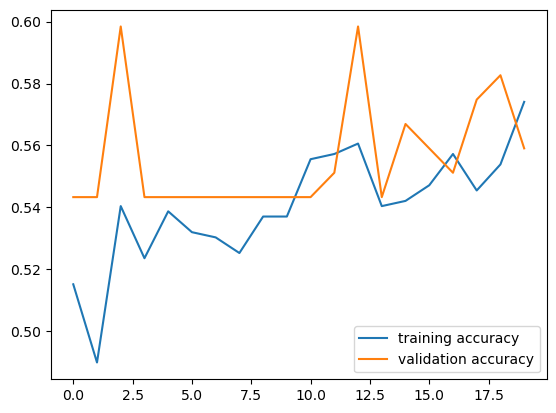

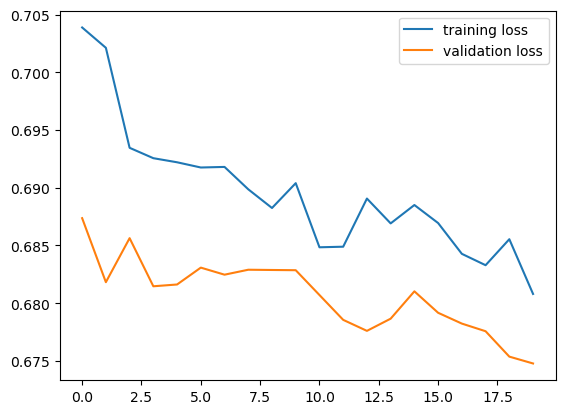

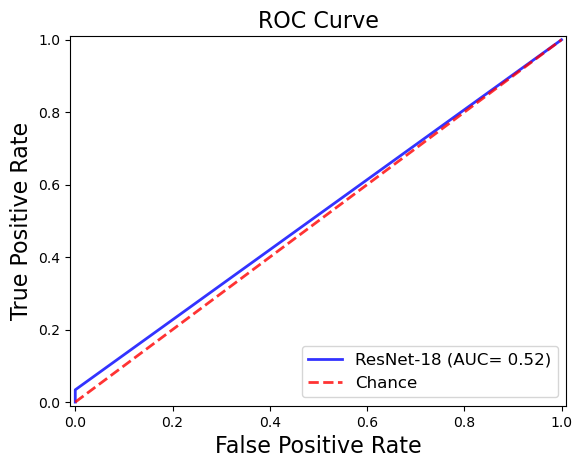

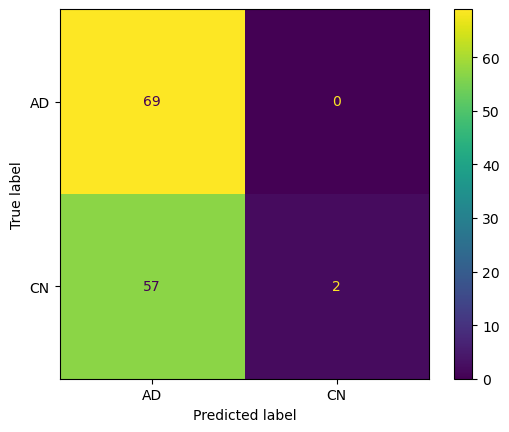

In [37]:
### Training, validation, and testing plot
plt.plot(history_model_cnn.history["accuracy"], label="training accuracy")
plt.plot(history_model_cnn.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_cnn.history["loss"], label="training loss")
plt.plot(history_model_cnn.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ResNet-18 (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_cnn)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

##### ViT

**Results**

In [38]:
y_pred_vit = model_vit.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_vit = np.argmax(y_pred_vit, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_vit)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_vit).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Standard ViT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 2s 329ms/step
Results for Across Y - (Standard ViT):
tp: 44
tn: 32
fp: 27
fn: 25
Accuracy:  0.59375
Sensitivity:  0.6376811594202898
Specificity:  0.5423728813559322
Precision:  0.6197183098591549
F1 Score: 0.6285714285714286
AUC: 0.590027020388111


**Plots**

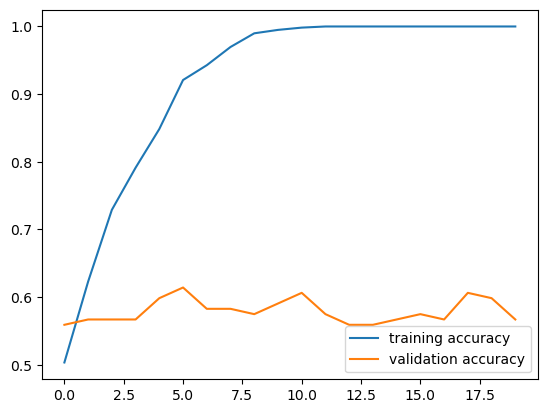

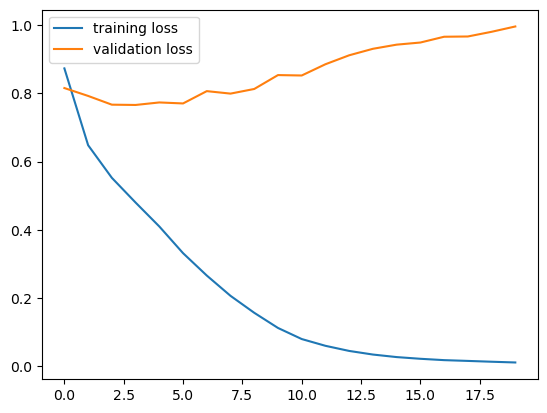

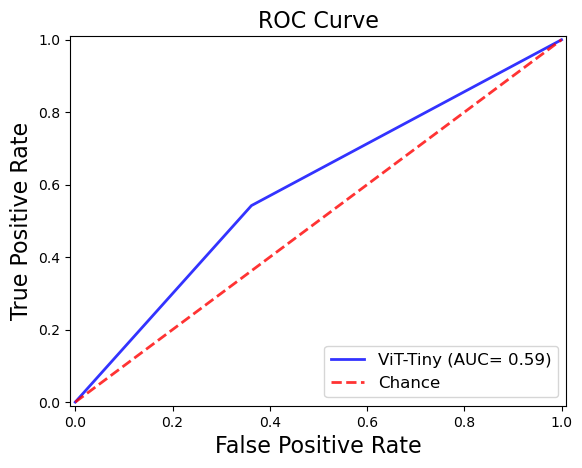

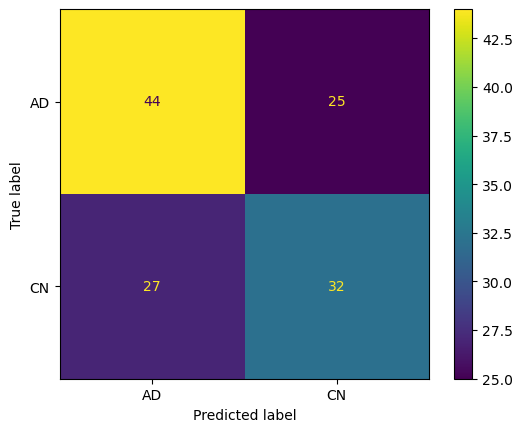

In [39]:
### Training, validation, and testing plot
plt.plot(history_model_vit.history["accuracy"], label="training accuracy")
plt.plot(history_model_vit.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_vit.history["loss"], label="training loss")
plt.plot(history_model_vit.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ViT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_vit)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

##### Pyramid ViT

**Results**

In [40]:
y_pred_pvt = model_pvt.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_pvt = np.argmax(y_pred_pvt, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_pvt)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_pvt).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Pyramid ViT-Tiny):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 4s 776ms/step
Results for Across Y - (Pyramid ViT-Tiny):
tp: 44
tn: 36
fp: 23
fn: 25
Accuracy:  0.625
Sensitivity:  0.6376811594202898
Specificity:  0.6101694915254238
Precision:  0.6567164179104478
F1 Score: 0.6470588235294118
AUC: 0.6239253254728567


**Plots**

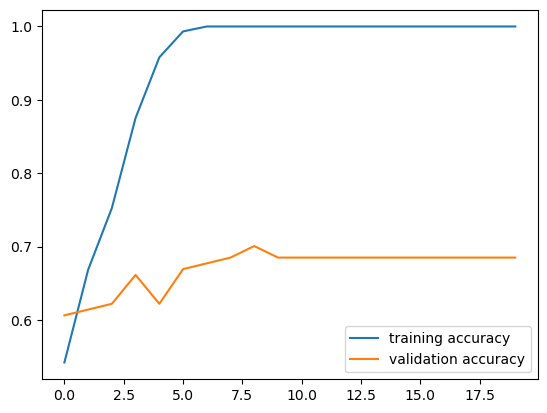

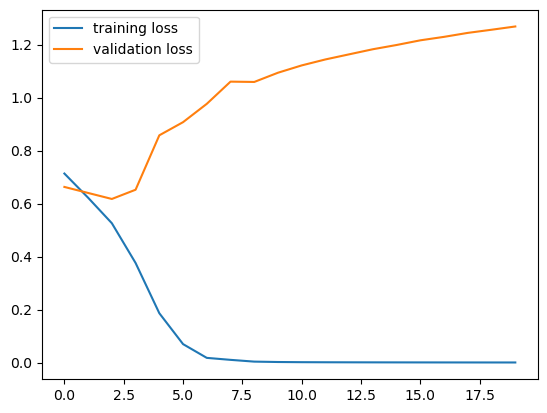

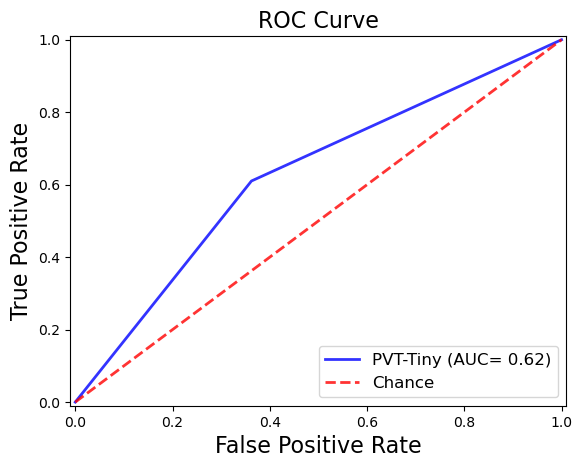

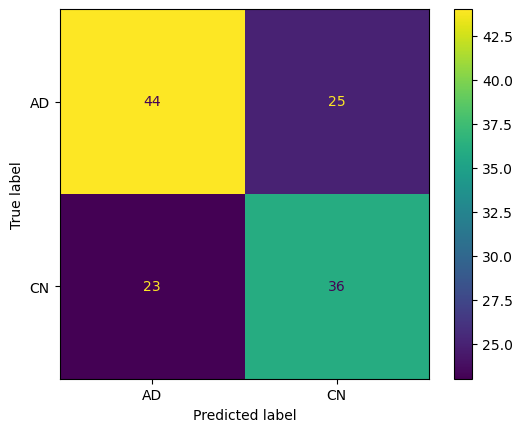

In [41]:
### Training, validation, and testing plot
plt.plot(history_model_pvt.history["accuracy"], label="training accuracy")
plt.plot(history_model_pvt.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_pvt.history["loss"], label="training loss")
plt.plot(history_model_pvt.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'PVT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_pvt)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

#### GNN model results

##### GCN

In [42]:
model_gcn.eval()

y_pred_bin_gnn = []
y_test_bin_y_axis = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model_gcn(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
        preds = out.argmax(dim=1)
        y_pred_bin_gnn.append(preds.cpu())
        y_test_bin_y_axis.append(batch.y.cpu())

y_pred_bin_gnn = torch.cat(y_pred_bin_gnn).numpy()
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_gnn)
roc_auc = auc(fpr, tpr)

# tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()
# changes above to below
tn,fp,fn,tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GCN):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GCN):
tp: 37
tn: 45
fp: 24
fn: 22
Accuracy:  0.640625
Sensitivity:  0.6271186440677966
Specificity:  0.6521739130434783
Precision:  0.6065573770491803
F1 Score: 0.6166666666666666
AUC: 0.6396462785556374


In [43]:
from sklearn.model_selection import StratifiedKFold

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

fold_results = []

for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X_gnn, y)):
    print(f"\n--- Fold {fold_idx+1}/{k_folds} ---")

    # Split this fold's train_val portion further into train/val for early stopping
    X_tv, y_tv = X_gnn[train_val_idx], y[train_val_idx]
    sex_tv, age_tv, fd_tv, site_tv = sex_bin[train_val_idx], age_raw[train_val_idx], fd_raw[train_val_idx], site_onehot[train_val_idx]
    X_te, y_te = X_gnn[test_idx], y[test_idx]
    sex_te, age_te, fd_te, site_te = sex_bin[test_idx], age_raw[test_idx], fd_raw[test_idx], site_onehot[test_idx]

    X_tr, X_va, y_tr, y_va, sex_tr, sex_va, age_tr, age_va, fd_tr, fd_va, site_tr, site_va= train_test_split(X_tv, y_tv, sex_tv, age_tv, fd_tv, site_tv, test_size=0.15, stratify=y_tv, random_state=random_state)

    age_m, age_s = age_tr.mean(), age_tr.std()
    fd_m, fd_s = fd_tr.mean(), fd_tr.std()
    z_age = lambda a: (a - age_m) / age_s
    z_fd  = lambda f: (f - fd_m) / fd_s

    fold_train_dataset = [matrix_to_data(X_tr[i], y_tr[i], sex_tr[i], z_age(age_tr[i]), z_fd(fd_tr[i]), site_tr[i]) for i in range(len(X_tr))]
    fold_val_dataset   = [matrix_to_data(X_va[i], y_va[i], sex_va[i], z_age(age_va[i]), z_fd(fd_va[i]), site_va[i]) for i in range(len(X_va))]
    fold_test_dataset  = [matrix_to_data(X_te[i], y_te[i], sex_te[i], z_age(age_te[i]), z_fd(fd_te[i]), site_te[i]) for i in range(len(X_te))]

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=gnn_batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=gnn_batch_size, shuffle=False)
    fold_test_loader  = DataLoader(fold_test_dataset,  batch_size=gnn_batch_size, shuffle=False)

    # Fresh model per fold
    torch.manual_seed(random_state)
    model = GCN(num_node_features=num_node_features, hidden_channels=32, dropout=0.5, num_covariates=3+num_sites).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00005)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience = 10
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in fold_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(fold_val_loader, model_gcn)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)

    # Evaluate this fold's held-out test portion
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in fold_test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    fold_acc = (preds == trues).mean()
    fold_auc = auc(*roc_curve(trues, preds)[:2])

    print(f"Fold {fold_idx+1}: acc={fold_acc:.4f}, auc={fold_auc:.4f}")
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'auc': fold_auc})

import numpy as np
accs = [r['accuracy'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
print(f"\nMean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


--- Fold 1/5 ---
Fold 1: acc=0.5471, auc=0.5360

--- Fold 2/5 ---
Fold 2: acc=0.5412, auc=0.5205

--- Fold 3/5 ---
Fold 3: acc=0.5235, auc=0.5091

--- Fold 4/5 ---
Fold 4: acc=0.6176, auc=0.5960

--- Fold 5/5 ---
Fold 5: acc=0.5562, auc=0.5311

Mean accuracy: 0.5571 ± 0.0321
Mean AUC: 0.5385 ± 0.0302


##### GAT

In [44]:
model_gat.eval()

y_pred_bin_gnn = []
y_test_bin_y_axis = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model_gat(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
        preds = out.argmax(dim=1)
        y_pred_bin_gnn.append(preds.cpu())
        y_test_bin_y_axis.append(batch.y.cpu())

y_pred_bin_gnn = torch.cat(y_pred_bin_gnn).numpy()
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_gnn)
roc_auc = auc(fpr, tpr)

tn,fp,fn,tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GAT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GAT):
tp: 33
tn: 55
fp: 14
fn: 26
Accuracy:  0.6875
Sensitivity:  0.559322033898305
Specificity:  0.7971014492753623
Precision:  0.7021276595744681
F1 Score: 0.6226415094339622
AUC: 0.6782117415868336


In [45]:
from sklearn.model_selection import StratifiedKFold
# what is k-fold cross-validation? it is a technique for assessing how the results of a statistical analysis will generalize to an independent dataset. it is mainly used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice. the data set is partitioned into k equal sized subsamples. of the k subsamples, a single subsample is retained as the validation data for testing the model, and the remaining k − 1 subsamples are used as training data. the cross-validation process is then repeated k times (the folds), with each of the k subsamples used exactly once as the validation data. the k results from the folds can then be averaged (or otherwise combined) to produce a single estimation.
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

fold_results = []

for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X_gnn, y)):
    print(f"\n--- Fold {fold_idx+1}/{k_folds} ---")

    # Split this fold's train_val portion further into train/val for early stopping
    X_tv, y_tv = X_gnn[train_val_idx], y[train_val_idx]
    sex_tv, age_tv, fd_tv, site_tv = sex_bin[train_val_idx], age_raw[train_val_idx], fd_raw[train_val_idx], site_onehot[train_val_idx]
    X_te, y_te = X_gnn[test_idx], y[test_idx]
    sex_te, age_te, fd_te, site_te = sex_bin[test_idx], age_raw[test_idx], fd_raw[test_idx], site_onehot[test_idx]

    X_tr, X_va, y_tr, y_va, sex_tr, sex_va, age_tr, age_va, fd_tr, fd_va, site_tr, site_va= train_test_split(X_tv, y_tv, sex_tv, age_tv, fd_tv, site_tv, test_size=0.15, stratify=y_tv, random_state=random_state)

    age_m, age_s = age_tr.mean(), age_tr.std()
    fd_m, fd_s = fd_tr.mean(), fd_tr.std()
    z_age = lambda a: (a - age_m) / age_s
    z_fd  = lambda f: (f - fd_m) / fd_s

    fold_train_dataset = [matrix_to_data(X_tr[i], y_tr[i], sex_tr[i], z_age(age_tr[i]), z_fd(fd_tr[i]), site_tr[i]) for i in range(len(X_tr))]
    fold_val_dataset   = [matrix_to_data(X_va[i], y_va[i], sex_va[i], z_age(age_va[i]), z_fd(fd_va[i]), site_va[i]) for i in range(len(X_va))]
    fold_test_dataset  = [matrix_to_data(X_te[i], y_te[i], sex_te[i], z_age(age_te[i]), z_fd(fd_te[i]), site_te[i]) for i in range(len(X_te))]


    fold_train_loader = DataLoader(fold_train_dataset, batch_size=gnn_batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=gnn_batch_size, shuffle=False)
    fold_test_loader  = DataLoader(fold_test_dataset,  batch_size=gnn_batch_size, shuffle=False)

    # Fresh model per fold
    torch.manual_seed(random_state + fold_idx)
    model = GAT(num_node_features=num_node_features, hidden_channels=32, dropout=0.5, heads=heads, num_covariates=3+num_sites).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00005)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience = 10
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in fold_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(fold_val_loader, model_gat)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)

    # Evaluate this fold's held-out test portion
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in fold_test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    fold_acc = (preds == trues).mean()
    fold_auc = auc(*roc_curve(trues, preds)[:2])

    print(f"Fold {fold_idx+1}: acc={fold_acc:.4f}, auc={fold_auc:.4f}")
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'auc': fold_auc})

import numpy as np
accs = [r['accuracy'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
print(f"\nMean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


--- Fold 1/5 ---
Fold 1: acc=0.6118, auc=0.6031

--- Fold 2/5 ---
Fold 2: acc=0.6000, auc=0.5992

--- Fold 3/5 ---
Fold 3: acc=0.6235, auc=0.6258

--- Fold 4/5 ---
Fold 4: acc=0.6824, auc=0.6724

--- Fold 5/5 ---
Fold 5: acc=0.6331, auc=0.6319

Mean accuracy: 0.6302 ± 0.0284
Mean AUC: 0.6265 ± 0.0262


In [46]:
torch.save(model_gat.state_dict(), 'gat_with_covariates2.pt')

# Ensembling

In [47]:
def train_one_model(seed, hidden_channels=32, dropout=0.5, weight_decay=weight_decay, heads=heads, patience=10):
    torch.manual_seed(seed)
    ensemble_model = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout, num_covariates=3+num_sites).to(device) # Add heads=heads if using GCN
    optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        ensemble_model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = ensemble_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(val_loader, ensemble_model)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = ensemble_model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    ensemble_model.load_state_dict(best_model_state)
    return ensemble_model

In [48]:
n_ensemble = 10
ensemble_seeds = [20, 201, 8, 12, 126, 508, 72, 100, 93, 23]  # Example seeds for reproducibility

ensemble_models = []
for seed in ensemble_seeds:
    print(f"Training model with seed {seed}...")
    m = train_one_model(seed)
    ensemble_models.append(m)
print("Done training ensemble.")

Training model with seed 20...
Training model with seed 201...
Training model with seed 8...
Training model with seed 12...
Training model with seed 126...
Training model with seed 508...
Training model with seed 72...
Training model with seed 100...
Training model with seed 93...
Training model with seed 23...
Done training ensemble.


In [49]:
for i, m in enumerate(ensemble_models):
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    acc = (preds == trues).mean()
    unique, counts = np.unique(preds, return_counts=True)
    print(f"Model {i} (seed {ensemble_seeds[i]}): acc={acc:.4f}, prediction distribution={dict(zip(unique, counts))}")

Model 0 (seed 20): acc=0.6641, prediction distribution={0: 84, 1: 44}
Model 1 (seed 201): acc=0.6484, prediction distribution={0: 78, 1: 50}
Model 2 (seed 8): acc=0.6875, prediction distribution={0: 65, 1: 63}
Model 3 (seed 12): acc=0.6484, prediction distribution={0: 46, 1: 82}
Model 4 (seed 126): acc=0.6484, prediction distribution={0: 72, 1: 56}
Model 5 (seed 508): acc=0.6328, prediction distribution={0: 58, 1: 70}
Model 6 (seed 72): acc=0.6953, prediction distribution={0: 68, 1: 60}
Model 7 (seed 100): acc=0.6641, prediction distribution={0: 84, 1: 44}
Model 8 (seed 93): acc=0.6562, prediction distribution={0: 77, 1: 51}
Model 9 (seed 23): acc=0.6562, prediction distribution={0: 77, 1: 51}


In [50]:
all_probs = []  # will hold each model's predicted probability of class 1, per test subject

for m in ensemble_models:
    m.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.covariates)
            prob = torch.softmax(out, dim=1)[:, 1]  # probability of class 1 (ASD)
            probs.append(prob.cpu())
    all_probs.append(torch.cat(probs).numpy())

# Get true labels once (same order every time since test_loader isn't shuffled)
y_test_bin_y_axis = []
with torch.no_grad():
    for batch in test_loader:
        y_test_bin_y_axis.append(batch.y.cpu())
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

# Average probabilities across ensemble members, then threshold at 0.5
avg_probs = np.mean(all_probs, axis=0)
y_pred_bin_ensemble = (avg_probs >= 0.5).astype(int)

#fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_ensemble)
# changed above to below
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, avg_probs)  # use avg_probs for ROC curve to get AUC

roc_auc = auc(fpr, tpr)

#tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_ensemble).flatten()
#tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()
tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GCN Ensemble):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GCN Ensemble):
tp: 37
tn: 51
fp: 18
fn: 22
Accuracy:  0.6875
Sensitivity:  0.6271186440677966
Specificity:  0.7391304347826086
Precision:  0.6727272727272727
F1 Score: 0.6491228070175439
AUC: 0.7435519528371408


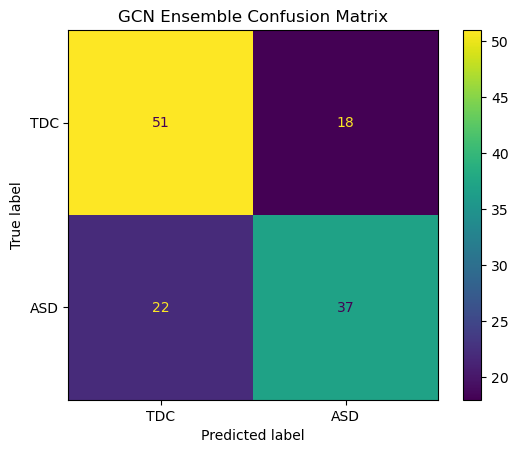

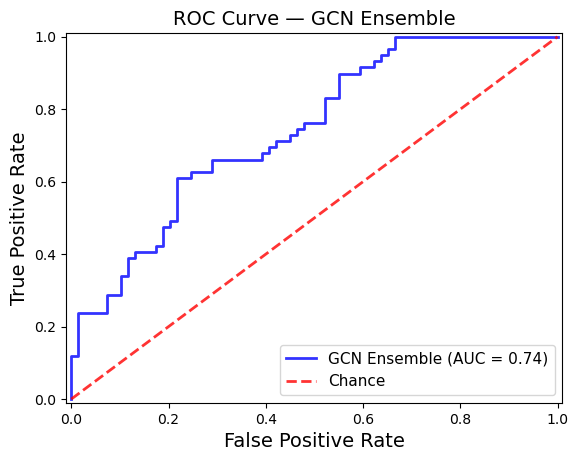

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix plot
cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TDC', 'ASD'])
disp.plot()
plt.title('GCN Ensemble Confusion Matrix')
plt.show()

# ROC curve plot
plt.plot(fpr, tpr, lw=2, color='b', label=f'GCN Ensemble (AUC = {roc_auc:.2f})', alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve — GCN Ensemble', fontsize=14)
plt.legend(loc="lower right", prop={'size': 11})
plt.show()

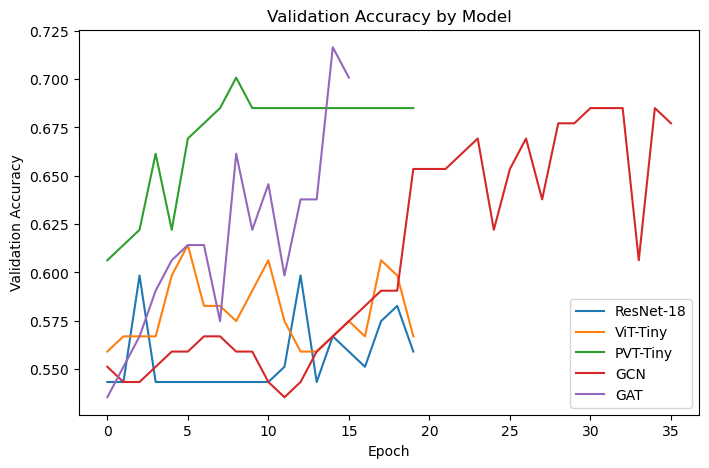

In [ ]:
import matplotlib.pyplot as plt

histories = {
    'ResNet-18':   history_model_cnn.history,
    'ViT-Tiny':    history_model_vit.history,
    'PVT-Tiny':    history_model_pvt.history,
    'GCN':         history_model_gnn,   # already a plain dict, not a keras History object
    'GAT':         history_model_gat,   # same
}

plt.figure(figsize=(8, 5))
for name, h in histories.items():
    plt.plot(h['val_accuracy'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Model')
plt.legend()
plt.show()